# F_S3 — Shape Classification Pipeline

Implements the full **global-to-shape decision hierarchy**:

1. **Gate 1** — MIC → global relationship strength (strong / intermediate / none)
2. **Gate 2** — |Pearson| & |Spearman| → Simple vs Complex
3. **Simple path, power gate** — power-law fit → Linear / Concave / Convex / next cubic–S–Threshold gate
4. **Complex path** — Branching / Threshold / Turning-point → subtypes

Reads the E-data experiment from `E/output/S3_snr_mic_sweep/`.

In [22]:
from __future__ import annotations

import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw):
        return it

warnings.filterwarnings('ignore')

def count_percent(count, total):
    count = int(count)
    total = int(total)
    return f'{count:,} ({count / total:.1%})' if total else f'{count:,} (N/A)'

def locate_repo_root() -> Path:
    for root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (root / 'D').is_dir() and (root / 'E').is_dir():
            return root
    raise FileNotFoundError('Could not locate repo root.')

REPO_ROOT = locate_repo_root()
INPUT_DIR = REPO_ROOT / 'E' / 'output' / 'S3_snr_mic_sweep'
OUT_DIR = REPO_ROOT / 'F' / 'output' / 'S3_shape_classification'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Gate 1 thresholds ──
MIC_STRONG = 0.8
MIC_INTERMEDIATE = 0.6

# ── Gate 2 thresholds ──
SIMPLE_CORR_THRESHOLD = 0.7

# ── Simple path thresholds ──
R2_POWER_THRESHOLD = 0.90          # min R² for adequate power-law fit
LINEAR_B_TOLERANCE = 0.05          # |b - 1| <= this → Linear
S_SHAPE_SHARPNESS_MAX = 6.0        # max deriv / median deriv below this → S-shaped (not threshold)
THRESHOLD_SHARPNESS_MIN = 6.0      # max deriv / median deriv above this → Threshold

# ── Complex path thresholds ──
BRANCHING_GAP_RATIO = 0.25         # gap / y_range in a bin to count as branching evidence
BRANCHING_MIN_BINS = 3             # min bins showing gaps
COMPLEX_THRESHOLD_DERIV_RATIO = 5.0  # derivative spike ratio for threshold detection

print(f'Gate 1: strong MIC >= {MIC_STRONG}, intermediate MIC >= {MIC_INTERMEDIATE}')
print(f'Gate 2: Simple when |r| >= {SIMPLE_CORR_THRESHOLD} AND |ρ| >= {SIMPLE_CORR_THRESHOLD}')
print(f'Simple path: power-law R² >= {R2_POWER_THRESHOLD}, linear |b−1| <= {LINEAR_B_TOLERANCE}')
print(f'Complex path: branching gap ratio >= {BRANCHING_GAP_RATIO} in >= {BRANCHING_MIN_BINS} bins')

Gate 1: strong MIC >= 0.8, intermediate MIC >= 0.6
Gate 2: Simple when |r| >= 0.7 AND |ρ| >= 0.7
Simple path: power-law R² >= 0.9, linear |b−1| <= 0.05
Complex path: branching gap ratio >= 0.25 in >= 3 bins


## Family catalogue

Ground-truth properties for each signal family, used for validation at the end.

In [23]:
# Family catalogue: ground-truth properties for each signal family.
# F17 (Quadratic peak) was removed in F; F18 is standalone.
FAMILY_CATALOGUE = {
    'F01': {'name': 'Linear positive',           'direction': 'positive',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F02': {'name': 'Linear negative',           'direction': 'negative',     'linearity': 'linear',              'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'none',                  'tp': 0},
    'F03': {'name': 'Power convex positive',     'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F04': {'name': 'Power convex negative',     'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F05': {'name': 'Power concave positive',    'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F06': {'name': 'Power concave negative',    'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F07': {'name': 'Saturation positive',       'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'saturation',            'tp': 0},
    'F08': {'name': 'Saturation negative',       'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'saturation',            'tp': 0},
    'F09': {'name': 'Log positive',              'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F10': {'name': 'Log negative',              'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F11': {'name': 'Exponential positive',      'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'convex', 'special_shape': 'none',                  'tp': 0},
    'F12': {'name': 'Exponential negative',      'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'concave','special_shape': 'none',                  'tp': 0},
    'F13': {'name': 'S-curve positive',          'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F14': {'name': 'S-curve negative',          'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'mixed',  'special_shape': 'S-curve',               'tp': 0},
    'F15': {'name': 'Threshold positive',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F16': {'name': 'Threshold negative',        'direction': 'negative',     'linearity': 'nonlinear',           'monotonicity': 'monotonic',     'curvature': 'N/A',    'special_shape': 'threshold',             'tp': 0},
    'F18': {'name': 'Quadratic valley (U)',       'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'valley',                'tp': 1},
    'F19': {'name': 'Spike',                     'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'spike',                 'tp': 1},
    'F20': {'name': 'Inverted Spike',            'direction': 'none/local',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'N/A',    'special_shape': 'inverted spike',        'tp': 1},
    'F21': {'name': 'Cubic',                     'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'cubic',                 'tp': 2},
    'F22': {'name': 'Oscillation',               'direction': 'none/mixed',   'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'mixed',  'special_shape': 'oscillation',           'tp': 'multiple'},
    'F23': {'name': 'Two Lines',                 'direction': 'positive',     'linearity': 'multi-branch linear', 'monotonicity': 'multi-branch',  'curvature': 'N/A',    'special_shape': 'two lines',             'tp': 0},
    'F24': {'name': 'Line and Parabola',         'direction': 'none/local',   'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'mixed',  'special_shape': 'line + parabola',       'tp': 1},
    'F25': {'name': 'Multi-regime threshold',    'direction': 'positive',     'linearity': 'multi-branch',        'monotonicity': 'multi-branch',  'curvature': 'convex', 'special_shape': 'overlapping J',         'tp': 'multiple'},
    'F26': {'name': 'Windowed threshold',        'direction': 'positive',     'linearity': 'nonlinear',           'monotonicity': 'non-monotonic', 'curvature': 'convex', 'special_shape': 'windowed J',            'tp': 'multiple'},
    'Null': {'name': 'No relationship',          'direction': 'N/A',          'linearity': 'N/A',                 'monotonicity': 'N/A',           'curvature': 'N/A',    'special_shape': 'none',                  'tp': 'N/A'},
}

# Build the expected shape_label mapping from the catalogue.
# This is the ground-truth: what shape should the classifier assign at high SNR?
EXPECTED_SHAPE = {}
for fid, props in FAMILY_CATALOGUE.items():
    if fid == 'Null':
        EXPECTED_SHAPE[fid] = 'no_global'
        continue
    d = props['direction']
    mono = props['monotonicity']
    lin = props['linearity']
    curv = props['curvature']
    shape = props['special_shape']
    tp = props['tp']

    # Simple monotonic families → gate2 = Simple
    if mono == 'monotonic':
        if lin == 'linear':
            EXPECTED_SHAPE[fid] = f'{d}_line'
        elif shape == 'S-curve':
            EXPECTED_SHAPE[fid] = f'{d}_s_shaped'
        elif shape == 'threshold':
            EXPECTED_SHAPE[fid] = f'{d}_threshold'
        elif curv == 'concave':
            EXPECTED_SHAPE[fid] = f'{d}_concave'
        elif curv == 'convex':
            EXPECTED_SHAPE[fid] = f'{d}_convex'
        else:
            EXPECTED_SHAPE[fid] = 'simple_other'
    # Non-monotonic / multi-branch → gate2 = Complex
    elif mono == 'non-monotonic':
        if tp == 1:
            EXPECTED_SHAPE[fid] = 'u_inv_u_spike'
        elif tp == 2:
            EXPECTED_SHAPE[fid] = 'complex_cubic'
        elif tp == 'multiple' and 'oscillat' in shape:
            EXPECTED_SHAPE[fid] = 'oscillatory'
        elif tp == 'multiple' and 'windowed' in shape:
            EXPECTED_SHAPE[fid] = 'multi_step_threshold'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'
    elif mono == 'multi-branch':
        if 'two lines' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'parabola' in shape:
            EXPECTED_SHAPE[fid] = '2_way_branching'
        elif 'overlapping' in shape or 'J' in shape:
            EXPECTED_SHAPE[fid] = 'n_way_branching'
        else:
            EXPECTED_SHAPE[fid] = 'complex_uncertain'

catalogue_df = pd.DataFrame.from_dict(FAMILY_CATALOGUE, orient='index').reset_index(names='family_id')
catalogue_df['expected_shape'] = catalogue_df['family_id'].map(EXPECTED_SHAPE)
print(f'{len(FAMILY_CATALOGUE)} families loaded')
display(catalogue_df[['family_id', 'name', 'monotonicity', 'curvature', 'special_shape', 'expected_shape']])

26 families loaded


,family_id,name,monotonicity,curvature,special_shape,expected_shape
0,F01,Linear positive,monotonic,N/A,none,positive_line
1,F02,Linear negative,monotonic,N/A,none,negative_line
2,F03,Power convex positive,monotonic,convex,none,positive_convex
3,F04,Power convex negative,monotonic,concave,none,negative_concave
4,F05,Power concave positive,monotonic,concave,none,positive_concave
5,F06,Power concave negative,monotonic,convex,none,negative_convex
6,F07,Saturation positive,monotonic,concave,saturation,positive_concave
7,F08,Saturation negative,monotonic,convex,saturation,negative_convex
8,F09,Log positive,monotonic,concave,none,positive_concave
9,F10,Log negative,monotonic,convex,none,negative_convex


## Load data

In [24]:
cases_df = pd.read_csv(INPUT_DIR / 'cases.csv', low_memory=False)
cases_df['_pt_idx'] = pd.to_numeric(cases_df['candidate_index'], errors='raise').astype(np.int64)
metrics_df = pd.read_parquet(INPUT_DIR / 'metrics_full.parquet')
pts = np.load(INPUT_DIR / 'scatter_points.npz')
x_all = pts['x']
y_all = pts['y']
del pts

if len(x_all) != len(cases_df) or len(y_all) != len(cases_df):
    raise ValueError('Scatter arrays and cases.csv must contain the same number of rows.')
if cases_df['case_id'].duplicated().any() or metrics_df['case_id'].duplicated().any():
    raise ValueError('case_id must be unique in both cases and metrics.')

# Filter to strong variant only while retaining each row's original point index.
strong_mask = cases_df['variant_level'] == 'strong'
cases_df = cases_df[strong_mask].reset_index(drop=True)

data = cases_df.merge(metrics_df, on='case_id', how='inner', validate='one_to_one')
data = data.reset_index(drop=True)
data['is_null'] = data['family_id'].eq('Null')
data['_pt_idx'] = pd.to_numeric(data['_pt_idx'], errors='raise').astype(np.int64)
if not data['_pt_idx'].between(0, len(x_all) - 1).all():
    raise IndexError('A mapped scatter-point index is outside the stored arrays.')
if data['_pt_idx'].duplicated().any():
    raise ValueError('Multiple classified cases map to the same scatter-point row.')

print(f'Loaded {len(data):,} strong cases × {x_all.shape[1]} points')
print(f'  Signal: {(~data["is_null"]).sum():,}   Null: {data["is_null"].sum():,}')
print(f'  Families: {sorted(data["family_id"].unique())}')
print(f'  MIC range: [{data["MIC"].min():.3f}, {data["MIC"].max():.3f}]')

Loaded 31,780 strong cases × 500 points
  Signal: 31,780   Null: 0
  Families: ['F01', 'F03', 'F05', 'F07', 'F13', 'F15', 'F18', 'F19', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26']
  MIC range: [0.129, 1.000]


## Gate 1 — Global relationship (MIC)

- **Strong**: MIC ≥ 0.8 → proceed to Gate 2
- **Intermediate**: 0.6 ≤ MIC < 0.8 → classification stops here
- **No global**: MIC < 0.6 → no relationship detected

In [25]:
def assign_gate1(mic):
    if mic >= MIC_STRONG:
        return 'strong_global'
    elif mic >= MIC_INTERMEDIATE:
        return 'intermediate_global'
    else:
        return 'no_global'

data['gate1'] = data['MIC'].apply(assign_gate1)

_g1_counts = data.groupby(['family_id', 'gate1']).size().unstack(fill_value=0)
_g1_counts = _g1_counts.reindex(
    columns=['strong_global', 'intermediate_global', 'no_global'], fill_value=0
).sort_index()
_g1_totals = _g1_counts.sum(axis=1)
_g1 = pd.DataFrame(index=_g1_counts.index)
_g1['family_name'] = _g1.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g1['Total'] = [count_percent(n, n) for n in _g1_totals]
for col in _g1_counts.columns:
    _g1[col] = [count_percent(n, total) for n, total in zip(_g1_counts[col], _g1_totals)]
print('=== Gate 1: Per-family MIC classification ===')
display(_g1)
print(f'\nOverall: {count_percent((data["gate1"]=="strong_global").sum(), len(data))} strong / '
      f'{count_percent((data["gate1"]=="intermediate_global").sum(), len(data))} intermediate / '
      f'{count_percent((data["gate1"]=="no_global").sum(), len(data))} no_global')

=== Gate 1: Per-family MIC classification ===


,family_name,Total,strong_global,intermediate_global,no_global
family_id,,,,,
F01,Linear positive,"2,270 (100.0%)",994 (43.8%),155 (6.8%),"1,121 (49.4%)"
F03,Power convex positive,"2,270 (100.0%)",806 (35.5%),235 (10.4%),"1,229 (54.1%)"
F05,Power concave positive,"2,270 (100.0%)",856 (37.7%),176 (7.8%),"1,238 (54.5%)"
F07,Saturation positive,"2,270 (100.0%)",55 (2.4%),582 (25.6%),"1,633 (71.9%)"
F13,S-curve positive,"2,270 (100.0%)","1,091 (48.1%)",114 (5.0%),"1,065 (46.9%)"
F15,Threshold positive,"2,270 (100.0%)","1,112 (49.0%)",99 (4.4%),"1,059 (46.7%)"
F18,Quadratic valley (U),"2,270 (100.0%)",916 (40.4%),173 (7.6%),"1,181 (52.0%)"
F19,Spike,"2,270 (100.0%)",0 (0.0%),0 (0.0%),"2,270 (100.0%)"
F21,Cubic,"2,270 (100.0%)",549 (24.2%),332 (14.6%),"1,389 (61.2%)"



Overall: 7,457 (23.5%) strong / 2,667 (8.4%) intermediate / 21,656 (68.1%) no_global


## Gate 2 — Simple or Complex

Applied only to **strong global** cases (MIC ≥ 0.8).

- **Simple**: |Pearson r| ≥ 0.7 AND |Spearman ρ| ≥ 0.7
- **Complex**: otherwise

In [26]:
mask_strong = data['gate1'] == 'strong_global'

data['gate2'] = None
data.loc[mask_strong, 'gate2'] = np.where(
    (data.loc[mask_strong, 'pearson_r'].abs() >= SIMPLE_CORR_THRESHOLD)
    & (data.loc[mask_strong, 'spearman_rho'].abs() >= SIMPLE_CORR_THRESHOLD),
    'Simple', 'Complex'
)

_g2_data = data.loc[mask_strong]
_g2_counts = _g2_data.groupby(['family_id', 'gate2']).size().unstack(fill_value=0)
_g2_counts = _g2_counts.reindex(columns=['Simple', 'Complex'], fill_value=0).sort_index()
_g2_totals = _g2_counts.sum(axis=1)
_g2 = pd.DataFrame(index=_g2_counts.index)
_g2['family_name'] = _g2.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
_g2['Total strong'] = [count_percent(n, n) for n in _g2_totals]
for col in _g2_counts.columns:
    _g2[col] = [count_percent(n, total) for n, total in zip(_g2_counts[col], _g2_totals)]
print('=== Gate 2: Per-family Simple vs Complex (strong_global only) ===')
display(_g2)
print(f'\nOverall strong: {count_percent(_g2_data["gate2"].eq("Simple").sum(), len(_g2_data))} Simple / '
      f'{count_percent(_g2_data["gate2"].eq("Complex").sum(), len(_g2_data))} Complex')

=== Gate 2: Per-family Simple vs Complex (strong_global only) ===


,family_name,Total strong,Simple,Complex
family_id,,,,
F01,Linear positive,994 (100.0%),994 (100.0%),0 (0.0%)
F03,Power convex positive,806 (100.0%),806 (100.0%),0 (0.0%)
F05,Power concave positive,856 (100.0%),856 (100.0%),0 (0.0%)
F07,Saturation positive,55 (100.0%),0 (0.0%),55 (100.0%)
F13,S-curve positive,"1,091 (100.0%)","1,091 (100.0%)",0 (0.0%)
F15,Threshold positive,"1,112 (100.0%)","1,111 (99.9%)",1 (0.1%)
F18,Quadratic valley (U),916 (100.0%),0 (0.0%),916 (100.0%)
F21,Cubic,549 (100.0%),233 (42.4%),316 (57.6%)
F22,Oscillation,987 (100.0%),0 (0.0%),987 (100.0%)



Overall strong: 5,091 (68.3%) Simple / 2,366 (31.7%) Complex


## Simple path — shape classification

Two-step cascade for **Simple** cases:

1. **Power-law fit**: y = a·x^b + c (R² ≥ 0.90)
   - |b − 1| ≤ 0.05 → **Line**
   - Otherwise a·b·(b−1) sign → **Concave** / **Convex**
2. **Next gate: cubic fit** (only when R² < 0.90):
   - ≥ 2 interior turning points → **Cubic**
   - Otherwise → **S-curve/Threshold**

In [27]:
def _power_law(x, a, b, c):
    return a * np.power(np.maximum(x, 1e-10), b) + c


def _fit_power_law(x, y):
    valid = np.isfinite(x) & np.isfinite(y) & (x > 1e-6)
    if valid.sum() < 10:
        return None
    x, y = x[valid], y[valid]
    slope = np.polyfit(x, y, 1)[0]
    a0 = slope
    for b0 in [1.0, 0.5, 2.0, 0.3, 3.0]:
        try:
            popt, _ = curve_fit(
                _power_law, x, y, p0=[a0, b0, np.median(y)],
                maxfev=5000,
                bounds=([-np.inf, 0.05, -np.inf], [np.inf, 8.0, np.inf]),
            )
            y_pred = _power_law(x, *popt)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            if r2 >= 0:
                return (*popt, r2)
        except (RuntimeError, ValueError):
            continue
    return None


def _fit_cubic(x, y):
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 10:
        return None
    x, y = x[valid], y[valid]
    try:
        coeffs = np.polyfit(x, y, 3)
        y_pred = np.polyval(coeffs, x)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
        return coeffs, r2
    except (np.RankWarning, np.linalg.LinAlgError):
        return None


def _count_turning_points(coeffs):
    """Count interior turning points of cubic in [0.05, 0.95]."""
    deriv = np.polyder(coeffs)
    roots = np.roots(deriv)
    real_roots = roots[np.isreal(roots)].real
    interior = real_roots[(real_roots >= 0.05) & (real_roots <= 0.95)]
    return len(interior), np.sort(interior)


def classify_simple_path(x, y):
    """Simple path: power-law → cubic cascade.
    Step 1: Power-law R² >= configured threshold → line / concave / convex
    Step 2: Cubic → >=2 turning points → cubic, otherwise → S-curve/threshold
    """
    # ── Step 1: Power-law ──
    pw = _fit_power_law(x, y)
    if pw is not None:
        a, b, c, r2 = pw
        if r2 >= R2_POWER_THRESHOLD:
            ab = a * b
            direction = 'positive' if ab > 0 else 'negative'
            details = {'step': 'power_law', 'a': a, 'b': b, 'c': c, 'r2': r2}
            if abs(b - 1) <= LINEAR_B_TOLERANCE:
                return f'{direction}_line', details
            curvature = a * b * (b - 1)
            if curvature < 0:
                return f'{direction}_concave', details
            else:
                return f'{direction}_convex', details

    # ── Step 2: Cubic/S/Threshold gate (power-law R² below threshold) ──
    cb = _fit_cubic(x, y)
    if cb is None:
        return 'simple_other', {'step': 'failed'}

    coeffs, r2_cubic = cb
    n_tp, tp_locs = _count_turning_points(coeffs)
    direction_val = float(np.polyval(coeffs, 1.0) - np.polyval(coeffs, 0.0))
    direction = 'positive' if direction_val >= 0 else 'negative'
    details = {'step': 'cubic', 'coeffs': coeffs.tolist(), 'r2': r2_cubic, 'n_tp': n_tp}

    if n_tp >= 2:
        return 'cubic_two_turning_point', details

    # Otherwise → S-curve/threshold
    return f'{direction}_s_threshold', details

print('Simple path helpers defined.')

Simple path helpers defined.


## Run full classification

In [28]:
import time

pt_idx = data['_pt_idx'].values
shape_labels = np.full(len(data), '', dtype=object)
shape_details = np.full(len(data), '', dtype=object)

mask_intermediate = data['gate1'] == 'intermediate_global'
mask_no_global = data['gate1'] == 'no_global'
shape_labels[mask_intermediate.values] = 'intermediate_global'
shape_labels[mask_no_global.values] = 'no_global'
shape_details[mask_intermediate.values] = '{}'
shape_details[mask_no_global.values] = '{}'

mask_simple = (data['gate2'] == 'Simple').values
mask_complex = (data['gate2'] == 'Complex').values
idx_simple = np.where(mask_simple)[0]

print(f'To classify: {len(idx_simple):,} Simple')
print(f'Complex (not sub-classified): {mask_complex.sum():,}')
print(f'Skipped: {mask_intermediate.sum():,} intermediate + {mask_no_global.sum():,} no_global')

t0 = time.time()
for i in tqdm(idx_simple, desc='Simple path'):
    pi = pt_idx[i]
    x = x_all[pi].astype(np.float64)
    y = y_all[pi].astype(np.float64)
    label, details = classify_simple_path(x, y)
    shape_labels[i] = label
    shape_details[i] = json.dumps(details, default=str)
print(f'Simple path: {len(idx_simple):,} cases in {time.time() - t0:.1f}s')

shape_labels[mask_complex] = 'complex'
shape_details[mask_complex] = '{}'

data['shape_label'] = shape_labels
data['shape_details'] = shape_details

SHAPE_TO_BROAD = {
    'positive_line': 'line', 'negative_line': 'line',
    'positive_concave': 'concave', 'negative_concave': 'concave',
    'positive_convex': 'convex', 'negative_convex': 'convex',
    'cubic_two_turning_point': 'cubic',
    'positive_s_threshold': 'S/threshold', 'negative_s_threshold': 'S/threshold',
    'simple_other': 'other',
}
BROAD_ORDER = ['line', 'concave', 'convex', 'cubic', 'S/threshold', 'other']
data['broad_shape'] = data['shape_label'].map(SHAPE_TO_BROAD)

_simple = data.loc[mask_simple].copy()
_simple['broad_shape'] = _simple['broad_shape'].fillna('other')

# Each stage table contains only the cases that actually entered that stage.
ROUTING_FAMILIES = ['F01', 'F03', 'F05', 'F13', 'F15', 'F21']
POWER_ROUTE_ORDER = ['Linear', 'Concave', 'Convex', 'Enter cubic/S/Threshold branch']
POWER_ROUTE_EXPECTED = {
    'F01': 'Linear',
    'F03': 'Convex',
    'F05': 'Concave',
    'F13': 'Enter cubic/S/Threshold branch',
    'F15': 'Enter cubic/S/Threshold branch',
    'F21': 'Enter cubic/S/Threshold branch',
}

power_routing = _simple[_simple['family_id'].isin(ROUTING_FAMILIES)].copy()
power_routing['power_route'] = power_routing['broad_shape'].map({
    'line': 'Linear',
    'concave': 'Concave',
    'convex': 'Convex',
}).fillna('Enter cubic/S/Threshold branch')
power_routing['expected_power_route'] = power_routing['family_id'].map(POWER_ROUTE_EXPECTED)
power_routing['route_correct'] = (
    power_routing['power_route'] == power_routing['expected_power_route']
)

power_counts = power_routing.groupby(['family_id', 'power_route']).size().unstack(fill_value=0)
power_counts = power_counts.reindex(
    index=ROUTING_FAMILIES, columns=POWER_ROUTE_ORDER, fill_value=0
)
power_totals = power_counts.sum(axis=1)
power_correct = power_routing.groupby('family_id')['route_correct'].sum().reindex(
    ROUTING_FAMILIES, fill_value=0
)
power_table = pd.DataFrame({
    'Family ID': ROUTING_FAMILIES,
    'Family': [FAMILY_CATALOGUE[f]['name'] for f in ROUTING_FAMILIES],
    'Total': [f'{int(n):,}' for n in power_totals],
})
for route in POWER_ROUTE_ORDER:
    power_table[route] = [
        count_percent(power_counts.loc[f, route], power_totals.loc[f])
        for f in ROUTING_FAMILIES
    ]
power_table['Accuracy'] = [
    (
        f'{int(power_correct.loc[f]):,}/{int(power_totals.loc[f]):,} '
        f'({power_correct.loc[f] / power_totals.loc[f]:.1%})'
    ) if power_totals.loc[f] else 'N/A'
    for f in ROUTING_FAMILIES
]

power_overall_correct = int(power_routing['route_correct'].sum())
power_overall_total = len(power_routing)
power_overall = {
    'Family ID': 'Overall',
    'Family': 'All six families',
    'Total': f'{power_overall_total:,}',
    **{
        route: count_percent((power_routing['power_route'] == route).sum(), power_overall_total)
        for route in POWER_ROUTE_ORDER
    },
    'Accuracy': (
        f'{power_overall_correct:,}/{power_overall_total:,} '
        f'({power_overall_correct / power_overall_total:.1%})'
    ),
}
power_table = pd.concat([power_table, pd.DataFrame([power_overall])], ignore_index=True)

print(
    f'\n=== Power-law routing gate: R² >= {R2_POWER_THRESHOLD:.2f}, '
    f'|b−1| <= {LINEAR_B_TOLERANCE:.2f} ==='
)
display(power_table)
print(
    f'Routing accuracy: {power_overall_correct:,}/{power_overall_total:,} '
    f'({power_overall_correct / power_overall_total:.1%})'
)

# Next gate: only cases routed out of the power-law gate.
next_gate = power_routing[
    power_routing['power_route'].eq('Enter cubic/S/Threshold branch')
].copy()
NEXT_ROUTE_ORDER = ['Cubic', 'Enter S/Threshold gate', 'Other/Uncertain']
next_gate['next_route'] = next_gate['broad_shape'].map({
    'cubic': 'Cubic',
    'S/threshold': 'Enter S/Threshold gate',
    'other': 'Other/Uncertain',
}).fillna('Other/Uncertain')
NEXT_ROUTE_EXPECTED = {
    'F13': 'Enter S/Threshold gate',
    'F15': 'Enter S/Threshold gate',
    'F21': 'Cubic',
}
next_gate['expected_next_route'] = next_gate['family_id'].map(NEXT_ROUTE_EXPECTED)
next_gate['route_correct'] = next_gate['next_route'] == next_gate['expected_next_route']
next_families = [f for f in ROUTING_FAMILIES if (next_gate['family_id'] == f).any()]
next_counts = next_gate.groupby(['family_id', 'next_route']).size().unstack(fill_value=0)
next_counts = next_counts.reindex(
    index=next_families, columns=NEXT_ROUTE_ORDER, fill_value=0
)
next_totals = next_counts.sum(axis=1)
next_correct = next_gate.groupby('family_id')['route_correct'].sum().reindex(
    next_families, fill_value=0
)
next_table = pd.DataFrame({
    'Family ID': next_families,
    'Family': [FAMILY_CATALOGUE[f]['name'] for f in next_families],
    'Total entering gate': [f'{int(n):,}' for n in next_totals],
})
for route in NEXT_ROUTE_ORDER:
    next_table[route] = [
        count_percent(next_counts.loc[f, route], next_totals.loc[f])
        for f in next_families
    ]
next_table['Accuracy'] = [
    (
        f'{int(next_correct.loc[f]):,}/{int(next_totals.loc[f]):,} '
        f'({next_correct.loc[f] / next_totals.loc[f]:.1%})'
    ) if next_totals.loc[f] else 'N/A'
    for f in next_families
]

next_overall_correct = int(next_gate['route_correct'].sum())
next_overall_total = len(next_gate)
next_overall = {
    'Family ID': 'Overall',
    'Family': 'All cases entering this gate',
    'Total entering gate': f'{next_overall_total:,}',
    **{
        route: count_percent((next_gate['next_route'] == route).sum(), next_overall_total)
        for route in NEXT_ROUTE_ORDER
    },
    'Accuracy': (
        f'{next_overall_correct:,}/{next_overall_total:,} '
        f'({next_overall_correct / next_overall_total:.1%})'
    ),
}
next_table = pd.concat([next_table, pd.DataFrame([next_overall])], ignore_index=True)

print('\n=== Cubic turning-point gate (only cases entering from the previous gate) ===')
display(next_table)
print(
    f'Gate accuracy: {next_overall_correct:,}/{next_overall_total:,} '
    f'({next_overall_correct / next_overall_total:.1%})'
)

power_table.to_csv(OUT_DIR / 'power_routing_table.csv', index=False)
next_table.to_csv(OUT_DIR / 'cubic_turning_point_gate_table.csv', index=False)


To classify: 5,091 Simple
Complex (not sub-classified): 2,366
Skipped: 2,667 intermediate + 21,656 no_global


Simple path: 100%|██████████| 5091/5091 [00:10<00:00, 469.36it/s]


Simple path: 5,091 cases in 10.8s

=== Power-law routing gate: R² >= 0.90, |b−1| <= 0.05 ===


,Family ID,Family,Total,Linear,Concave,Convex,Enter cubic/S/Threshold branch,Accuracy
0,F01,Linear positive,994,874 (87.9%),0 (0.0%),14 (1.4%),106 (10.7%),874/994 (87.9%)
1,F03,Power convex positive,806,0 (0.0%),0 (0.0%),806 (100.0%),0 (0.0%),806/806 (100.0%)
2,F05,Power concave positive,856,0 (0.0%),855 (99.9%),0 (0.0%),1 (0.1%),855/856 (99.9%)
3,F13,S-curve positive,"1,091",0 (0.0%),0 (0.0%),448 (41.1%),643 (58.9%),"643/1,091 (58.9%)"
4,F15,Threshold positive,"1,111",0 (0.0%),0 (0.0%),0 (0.0%),"1,111 (100.0%)","1,111/1,111 (100.0%)"
5,F21,Cubic,233,0 (0.0%),0 (0.0%),0 (0.0%),233 (100.0%),233/233 (100.0%)
6,Overall,All six families,"5,091",874 (17.2%),855 (16.8%),"1,268 (24.9%)","2,094 (41.1%)","4,522/5,091 (88.8%)"


Routing accuracy: 4,522/5,091 (88.8%)

=== Cubic turning-point gate (only cases entering from the previous gate) ===


,Family ID,Family,Total entering gate,Cubic,Enter S/Threshold gate,Other/Uncertain,Accuracy
0,F01,Linear positive,106,0 (0.0%),106 (100.0%),0 (0.0%),0/106 (0.0%)
1,F05,Power concave positive,1,0 (0.0%),1 (100.0%),0 (0.0%),0/1 (0.0%)
2,F13,S-curve positive,643,643 (100.0%),0 (0.0%),0 (0.0%),0/643 (0.0%)
3,F15,Threshold positive,"1,111","1,111 (100.0%)",0 (0.0%),0 (0.0%),"0/1,111 (0.0%)"
4,F21,Cubic,233,233 (100.0%),0 (0.0%),0 (0.0%),233/233 (100.0%)
5,Overall,All cases entering this gate,"2,094","1,987 (94.9%)",107 (5.1%),0 (0.0%),"233/2,094 (11.1%)"


Gate accuracy: 233/2,094 (11.1%)


## Save results

In [29]:
output_cols = [
    'case_id', '_pt_idx', 'family_id', 'family_name', 'variant_name', 'variant_level',
    'nominal_snr', 'actual_snr', 'repeat',
    'MIC', 'pearson_r', 'spearman_rho',
    'gate1', 'gate2', 'shape_label', 'broad_shape', 'shape_details',
]

result = data[[c for c in output_cols if c in data.columns]].copy()
result = result.rename(columns={'_pt_idx': 'scatter_point_index'})
result.to_parquet(OUT_DIR / 'shape_classification.parquet', index=False)
result.to_csv(OUT_DIR / 'shape_classification.csv', index=False)

print(f'Saved {len(result):,} rows to {OUT_DIR.relative_to(REPO_ROOT)}/')

Saved 31,780 rows to F/output/S3_shape_classification/


## Summary & validation

Compare predicted shape labels against the known `family_id` ground truth.

In [30]:
# Overall shape label distribution
print('=== Shape label distribution ===')
_shape_counts = data['shape_label'].value_counts()
_shape_distribution = pd.DataFrame({
    'shape_label': _shape_counts.index,
    'Count (share)': [count_percent(n, len(data)) for n in _shape_counts],
})
print(_shape_distribution.to_string(index=False))
print()

# Evaluate the current Simple-path label resolution rather than comparing it
# with finer Complex labels that this notebook does not attempt to predict.
EXPECTED_BROAD_SHAPE = {
    'F01': 'line', 'F02': 'line',
    'F03': 'convex', 'F04': 'concave',
    'F05': 'concave', 'F06': 'convex',
    'F07': 'concave', 'F08': 'convex',
    'F09': 'concave', 'F10': 'convex',
    'F11': 'convex', 'F12': 'concave',
    'F13': 'S/threshold', 'F14': 'S/threshold',
    'F15': 'S/threshold', 'F16': 'S/threshold',
    'F21': 'cubic',
}

high_snr = data[pd.to_numeric(data['actual_snr'], errors='coerce') >= 10].copy()
high_snr['expected_broad_shape'] = high_snr['family_id'].map(EXPECTED_BROAD_SHAPE)
eligible_high = high_snr[high_snr['expected_broad_shape'].notna()].copy()
eligible_high['entered_simple'] = eligible_high['gate2'].eq('Simple')
shape_eval = eligible_high[eligible_high['entered_simple']].copy()
shape_eval['predicted_broad_shape'] = shape_eval['broad_shape'].fillna('other')
shape_eval['correct'] = (
    shape_eval['predicted_broad_shape'] == shape_eval['expected_broad_shape']
)

coverage = eligible_high.groupby('family_id', as_index=False).agg(
    family_name=('family_name', 'first'),
    expected_broad_shape=('expected_broad_shape', 'first'),
    high_snr_input=('case_id', 'size'),
    entered_simple=('entered_simple', 'sum'),
)
coverage['simple_path_coverage'] = coverage['entered_simple'] / coverage['high_snr_input']
shape_accuracy = shape_eval.groupby('family_id', as_index=False).agg(
    correctly_classified=('correct', 'sum'),
    top_predicted=('predicted_broad_shape', lambda s: s.value_counts().index[0]),
)
accuracy = coverage.merge(shape_accuracy, on='family_id', how='left')
accuracy['correctly_classified'] = accuracy['correctly_classified'].fillna(0).astype(int)
accuracy['conditional_accuracy'] = np.divide(
    accuracy['correctly_classified'], accuracy['entered_simple'],
    out=np.full(len(accuracy), np.nan), where=accuracy['entered_simple'].to_numpy() > 0,
)

print('=== High-SNR Simple-path coverage and broad-shape accuracy ===')
accuracy_display = accuracy[[
    'family_id', 'family_name', 'expected_broad_shape', 'high_snr_input',
    'entered_simple', 'correctly_classified', 'top_predicted',
]].copy()
accuracy_display['High-SNR input'] = [count_percent(n, n) for n in accuracy['high_snr_input']]
accuracy_display['Entered Simple'] = [
    count_percent(n, total) for n, total in zip(accuracy['entered_simple'], accuracy['high_snr_input'])
]
accuracy_display['Correct'] = [
    count_percent(n, total) for n, total in zip(accuracy['correctly_classified'], accuracy['entered_simple'])
]
accuracy_display = accuracy_display[[
    'family_id', 'family_name', 'expected_broad_shape', 'High-SNR input',
    'Entered Simple', 'top_predicted', 'Correct',
]]
print(accuracy_display.to_string(index=False))
overall_coverage = len(shape_eval) / len(eligible_high) if len(eligible_high) else np.nan
overall_accuracy = shape_eval['correct'].mean() if len(shape_eval) else np.nan
print(f'\nSimple-path coverage: {len(shape_eval):,}/{len(eligible_high):,} ({overall_coverage:.1%})')
print(f'Conditional broad-shape accuracy: {shape_eval["correct"].sum():,}/{len(shape_eval):,} ({overall_accuracy:.1%})')
print('Complex families are excluded here because this notebook currently reports only the broad label Complex.')
accuracy.to_csv(OUT_DIR / 'simple_path_broad_accuracy_high_snr.csv', index=False)

=== Shape label distribution ===
            shape_label  Count (share)
              no_global 21,656 (68.1%)
    intermediate_global   2,667 (8.4%)
                complex   2,366 (7.4%)
cubic_two_turning_point   1,987 (6.3%)
        positive_convex   1,268 (4.0%)
          positive_line     874 (2.8%)
       positive_concave     855 (2.7%)
   positive_s_threshold     107 (0.3%)

=== High-SNR Simple-path coverage and broad-shape accuracy ===
family_id            family_name expected_broad_shape High-SNR input Entered Simple top_predicted      Correct
      F01        Linear positive                 line   871 (100.0%)   871 (100.0%)          line  858 (98.5%)
      F03  Power convex positive               convex   874 (100.0%)    806 (92.2%)        convex 806 (100.0%)
      F05 Power concave positive              concave   867 (100.0%)    849 (97.9%)       concave 849 (100.0%)
      F07    Saturation positive              concave   862 (100.0%)       0 (0.0%)           NaN      0 (N/

In [31]:
# Cross-tabulation: family × shape_label for high SNR
print('=== Family × Shape Label (SNR >= 10, strong_global only) ===')
ct_counts = high_snr[high_snr['gate1'] == 'strong_global'].groupby(
    ['family_id', 'shape_label']
).size().unstack(fill_value=0)
ct_totals = ct_counts.sum(axis=1)
ct = pd.DataFrame(index=ct_counts.index)
ct['family_name'] = ct.index.map(lambda f: FAMILY_CATALOGUE.get(f, {}).get('name', ''))
ct['Total'] = [count_percent(n, n) for n in ct_totals]
for col in ct_counts.columns:
    ct[col] = [count_percent(n, total) for n, total in zip(ct_counts[col], ct_totals)]
display(ct)

=== Family × Shape Label (SNR >= 10, strong_global only) ===


,family_name,Total,complex,cubic_two_turning_point,positive_concave,positive_convex,positive_line
family_id,,,,,,,
F01,Linear positive,871 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),13 (1.5%),858 (98.5%)
F03,Power convex positive,806 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),806 (100.0%),0 (0.0%)
F05,Power concave positive,849 (100.0%),0 (0.0%),0 (0.0%),849 (100.0%),0 (0.0%),0 (0.0%)
F07,Saturation positive,55 (100.0%),55 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F13,S-curve positive,870 (100.0%),0 (0.0%),422 (48.5%),0 (0.0%),448 (51.5%),0 (0.0%)
F15,Threshold positive,867 (100.0%),0 (0.0%),867 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F18,Quadratic valley (U),864 (100.0%),864 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
F21,Cubic,549 (100.0%),316 (57.6%),233 (42.4%),0 (0.0%),0 (0.0%),0 (0.0%)
F22,Oscillation,869 (100.0%),869 (100.0%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)


## Diagnostic — misclassified F13 S-curve cases

This block reports every F13 case that entered the Simple path but was not labelled `S/threshold`. It also plots representative cases from each erroneous destination so that power-law truncation and spurious cubic turning points can be inspected directly.

=== Misclassified F13 S-curve cases ===
F13 Simple input: 1,091
Misclassified: 1,091 (100.0%)


,broad_shape,shape_label,Count (proportion)
0,convex,positive_convex,448 (41.1%)
1,cubic,cubic_two_turning_point,643 (58.9%)



First 30 misclassified cases (the complete table is saved as CSV):


,case_id,scatter_point_index,variant_name,actual_snr,MIC,pearson_r,spearman_rho,broad_shape,shape_label,fit_step,power_b,fit_r2,n_turning_points
9306,S032007,32006,k_15_c_0.5,inf,1.0,0.951651,1.000000,convex,positive_convex,power_law,1.141156,0.908295,NaN
9533,S032234,32233,k_15_c_0.5,inf,1.0,0.951446,1.000000,convex,positive_convex,power_law,1.127409,0.907405,NaN
9760,S032461,32460,k_15_c_0.5,inf,1.0,0.954629,1.000000,convex,positive_convex,power_law,1.069270,0.911948,NaN
9987,S032688,32687,k_15_c_0.5,inf,1.0,0.950222,1.000000,convex,positive_convex,power_law,1.155674,0.906162,NaN
10214,S032915,32914,k_15_c_0.5,inf,1.0,0.951975,1.000000,convex,positive_convex,power_law,1.143875,0.909097,NaN
10441,S033142,33141,k_15_c_0.5,inf,1.0,0.950557,1.000000,convex,positive_convex,power_law,1.109108,0.905155,NaN
10668,S033369,33368,k_15_c_0.5,inf,1.0,0.953267,1.000000,convex,positive_convex,power_law,1.122280,0.910663,NaN
10895,S033596,33595,k_15_c_0.5,inf,1.0,0.952228,1.000000,convex,positive_convex,power_law,1.096939,0.907935,NaN
11122,S033823,33822,k_15_c_0.5,inf,1.0,0.952350,1.000000,convex,positive_convex,power_law,1.155624,0.910117,NaN
11349,S034050,34049,k_15_c_0.5,inf,1.0,0.952390,1.000000,convex,positive_convex,power_law,1.104410,0.908496,NaN


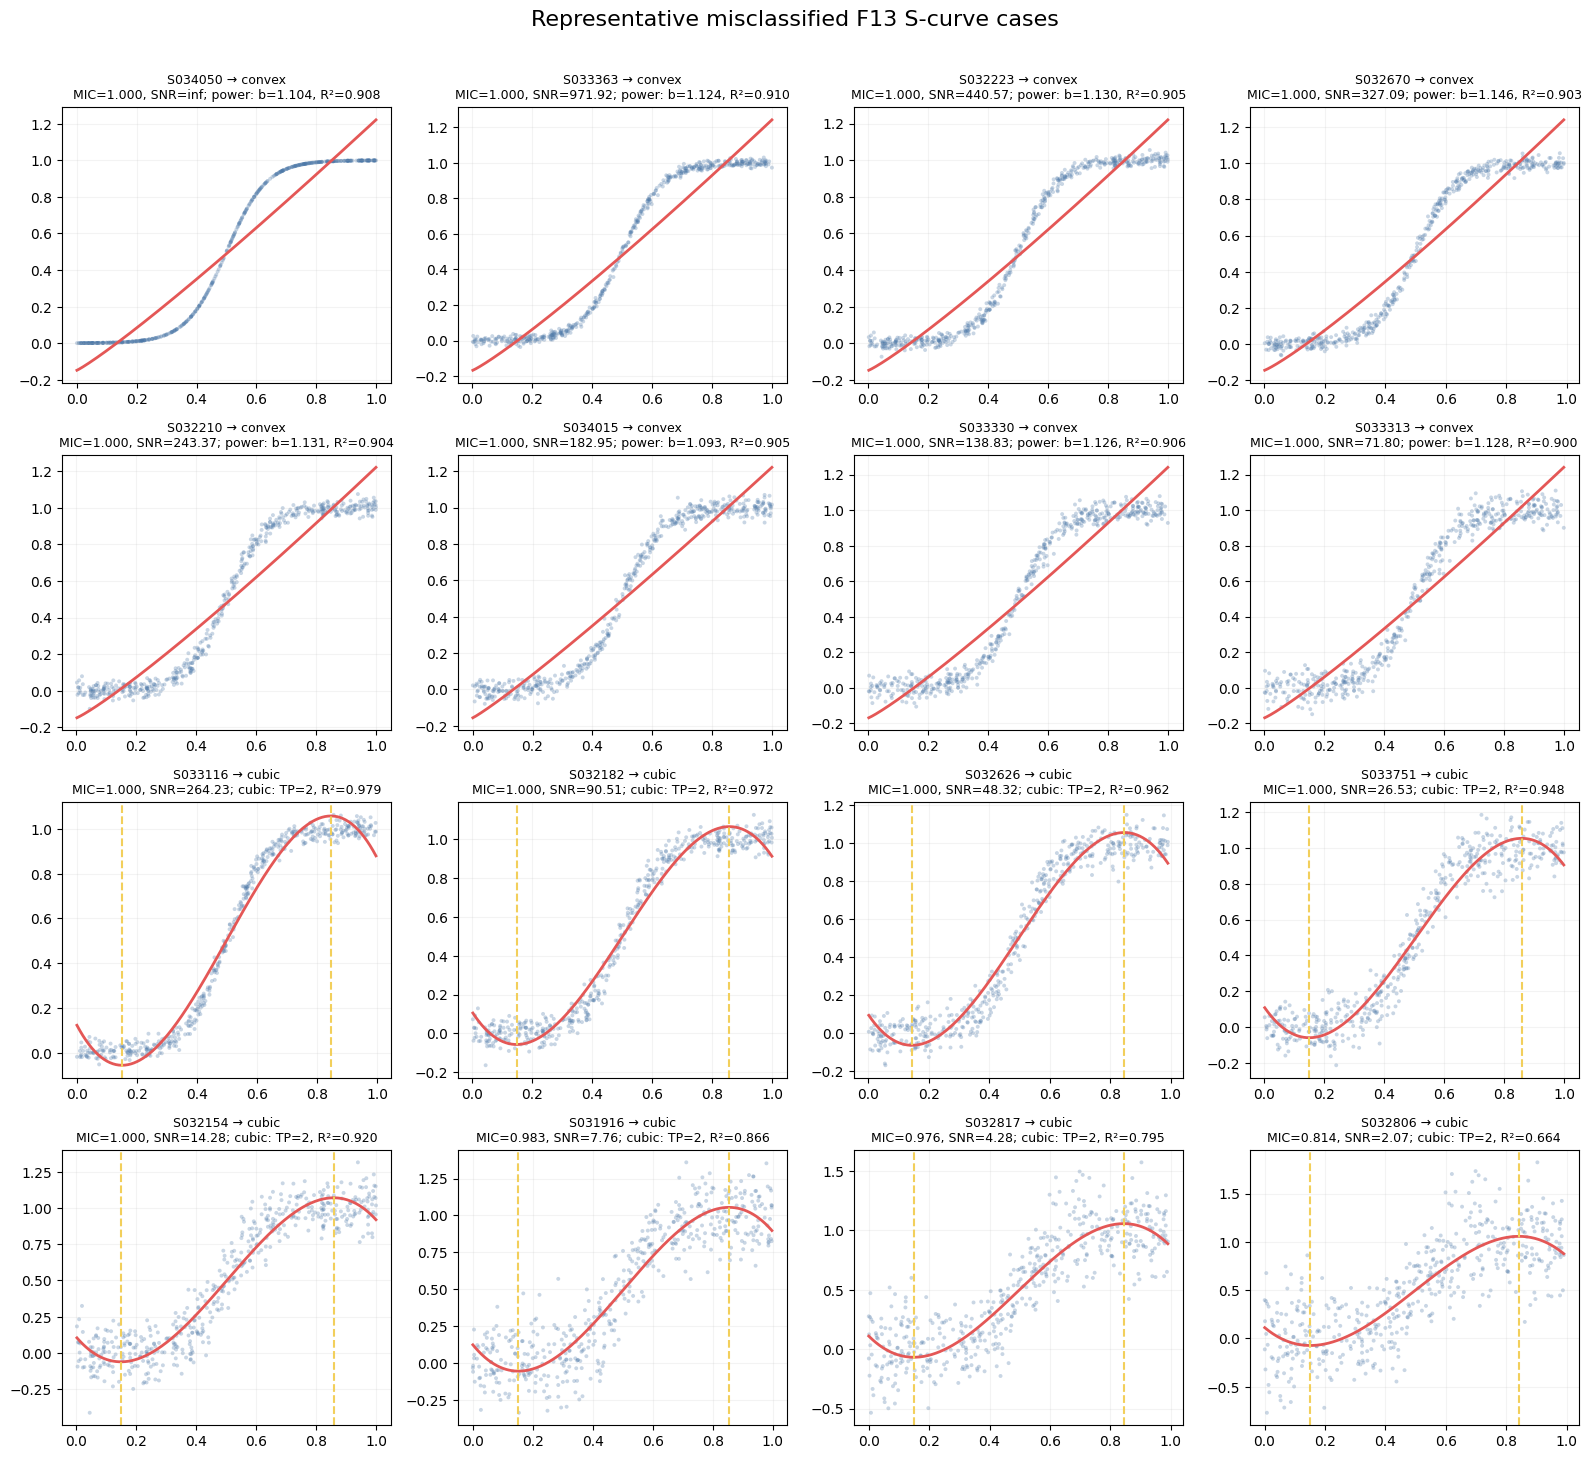

Saved complete case table: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/S3_shape_classification/misclassified_F13_cases.csv
Saved representative plot: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/F/output/S3_shape_classification/misclassified_F13_examples.png


In [32]:
import matplotlib.pyplot as plt

F13_EXPECTED_BROAD = 'S/threshold'
F13_EXAMPLES_PER_DESTINATION = 8

f13_simple = data[(data['family_id'] == 'F13') & data['gate2'].eq('Simple')].copy()
f13_misclassified = f13_simple[~f13_simple['broad_shape'].eq(F13_EXPECTED_BROAD)].copy()

def _decode_shape_details(value):
    try:
        return json.loads(value) if isinstance(value, str) else (value or {})
    except (TypeError, json.JSONDecodeError):
        return {}

decoded = f13_misclassified['shape_details'].map(_decode_shape_details)
f13_misclassified['fit_step'] = decoded.map(lambda d: d.get('step'))
f13_misclassified['power_b'] = decoded.map(lambda d: d.get('b', np.nan))
f13_misclassified['fit_r2'] = decoded.map(lambda d: d.get('r2', np.nan))
f13_misclassified['n_turning_points'] = decoded.map(lambda d: d.get('n_tp', np.nan))

destination_counts = f13_misclassified.groupby(
    ['broad_shape', 'shape_label'], as_index=False
).size().rename(columns={'size': 'count'})
destination_counts['proportion_of_F13_simple'] = (
    destination_counts['count'] / len(f13_simple)
)
destination_counts['Count (proportion)'] = [
    count_percent(n, len(f13_simple)) for n in destination_counts['count']
]

print('=== Misclassified F13 S-curve cases ===')
print(f'F13 Simple input: {len(f13_simple):,}')
print(f'Misclassified: {count_percent(len(f13_misclassified), len(f13_simple))}')
display(destination_counts[['broad_shape', 'shape_label', 'Count (proportion)']])

diagnostic_columns = [
    'case_id', '_pt_idx', 'variant_name', 'actual_snr', 'MIC', 'pearson_r',
    'spearman_rho', 'broad_shape', 'shape_label', 'fit_step', 'power_b',
    'fit_r2', 'n_turning_points',
]
f13_diagnostic_table = f13_misclassified[diagnostic_columns].rename(
    columns={'_pt_idx': 'scatter_point_index'}
).sort_values(['broad_shape', 'actual_snr', 'case_id'], ascending=[True, False, True])
f13_diagnostic_table.to_csv(OUT_DIR / 'misclassified_F13_cases.csv', index=False)
print('\nFirst 30 misclassified cases (the complete table is saved as CSV):')
display(f13_diagnostic_table.head(30))

# Select cases deterministically across the observed SNR range for each wrong destination.
representative_indices = []
for destination, group in f13_misclassified.groupby('broad_shape', sort=True):
    group = group.sort_values(['actual_snr', 'case_id']).copy()
    n_take = min(F13_EXAMPLES_PER_DESTINATION, len(group))
    positions = np.unique(np.linspace(0, len(group) - 1, n_take).round().astype(int))
    representative_indices.extend(group.iloc[positions].index.tolist())

representatives = f13_misclassified.loc[representative_indices].sort_values(
    ['broad_shape', 'actual_snr', 'case_id'], ascending=[True, False, True]
)
n_cols = 4
n_rows = max(1, math.ceil(len(representatives) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.6 * n_rows), squeeze=False)

for ax, (_, row) in zip(axes.ravel(), representatives.iterrows()):
    point_index = int(row['_pt_idx'])
    x = x_all[point_index].astype(float)
    y = y_all[point_index].astype(float)
    valid = np.isfinite(x) & np.isfinite(y)
    ax.scatter(x[valid], y[valid], s=8, alpha=0.30, color='#4c78a8', edgecolors='none')

    details = _decode_shape_details(row['shape_details'])
    grid = np.linspace(max(1e-6, np.nanmin(x[valid])), np.nanmax(x[valid]), 300)
    if details.get('step') == 'power_law':
        fitted = _power_law(grid, details['a'], details['b'], details['c'])
        ax.plot(grid, fitted, color='#e45756', lw=2)
        method_text = f"power: b={details['b']:.3f}, R²={details['r2']:.3f}"
    elif details.get('step') == 'cubic':
        coeffs = np.asarray(details['coeffs'], dtype=float)
        ax.plot(grid, np.polyval(coeffs, grid), color='#e45756', lw=2)
        roots = np.roots(np.polyder(coeffs))
        interior = np.sort(roots[np.isreal(roots)].real)
        interior = interior[(interior >= 0.05) & (interior <= 0.95)]
        for root in interior:
            ax.axvline(root, color='#f2cf5b', lw=1.5, ls='--')
        method_text = f"cubic: TP={len(interior)}, R²={details['r2']:.3f}"
    else:
        method_text = str(details.get('step', 'unknown'))

    ax.set_title(
        f"{row['case_id']} → {row['broad_shape']}\n"
        f"MIC={row['MIC']:.3f}, SNR={row['actual_snr']:.2f}; {method_text}",
        fontsize=9,
    )
    ax.grid(alpha=0.15)

for ax in axes.ravel()[len(representatives):]:
    ax.axis('off')

fig.suptitle('Representative misclassified F13 S-curve cases', fontsize=16, y=1.01)
fig.tight_layout()
diagnostic_figure_path = OUT_DIR / 'misclassified_F13_examples.png'
fig.savefig(diagnostic_figure_path, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved complete case table: {OUT_DIR / "misclassified_F13_cases.csv"}')
print(f'Saved representative plot: {diagnostic_figure_path}')